<a href="https://colab.research.google.com/github/zry3fr/undergrad_ml_assignments/blob/main/COMPLETE_03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. A model is "linear" when it is linear in its parameters, not in its variables themselves. This means that the parameters, or coefficients, are only multipled by variables and added together. There are no powers or functions applied to the coefficients. The equation is a weighted sum of the predictor variables, not that the predictors themselves must be linear.
2. A dummy variable coefficient represents the difference in the predicted outcome, between that group and the reference group, which is the group left out. The intercept represents the expected mean value of the reference group. The dummy's coefficient tells you how much higher or lower the outcome is when the dummy equals 1 compared to that baseline.
3. Yes linear regression can be used for classification, however, it is not ideal for classification problems. Linear regression outputs continous values ranging from negative infinity to positive infinity. Classification is categorical and requires values between 0 and 1 to be interpreted as probabilities.
4. A sign that your linear model is over-fitting is high accuracy on training data but low accuracy on testing data. Another sign is high standard errors for coefficients, which include large fluctuations in coefficients when the data changes. Another sign is over all complexity of the model when it possesses too many features relative to observations.
5. Multicolinearity happens when highly correlated variables cancel one another out and give the model a "mushy" and "high variance" quality, making it hard to isolate their individual effects on the outcome. **Stage 1:** Regress one problematic variable on the others to isolate the part that is predictable from them. **Stage 2:** Use the residual, which is the part not explained by others, in the main regression. If most of the variable can already be predicted by others, meaning little residual left, it shows strong multicolinearity. This means the model struggles to distinguish their separate effects.
6. You can incorporate nonlinear relationships by transforming x or y to linearize the relationship. For example, logarithmic transformations (log(x) or log (y)). This type of transformation models percent changes rather than unit changes and is especially helpful when the relationship is exponential or when the data is highly skewed.
7. The slope coefficient represents the predicted change in the outcome variable (y) for a one unit increase in (x), assuming all other variables remain constant. It defines the steepness of the line of best fit, showing how much (y) changes when (x) increases by one unit.
8. The difference between the train/test split and k-fold cross validation is that a train/test split is a single analysis on one specific division of data, while k-fold cross validation is a repeated analysis across multiple divisions of data. For a train/test split, data is split once into training and testing sets, results depend heavily on how the split is done, and it is overall more simpler. For a k-fold cross validation, data is split into k parts and the model is trained/tested k times, each part gets used as a test set once, and it is overall more reliable for model performance.
9. k is typically selected as 5 or 10, because these values provide a good balance efficiency and reliability. k is chosen based on tradeoffs. For example, smaller k has more biased estimates, meaning the model is trained on less data, but has lower computational cost. Larger k has less biased estimates, meaning the model is trained on more data and making it more accurate, but has higher computational cost.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.



1.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
nyc = pd.read_csv('/content/Q1_clean.csv')
nyc.head(10)

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt
5,290,96.0,Manhattan,Apartment,Entire home/apt
6,170,98.0,Brooklyn,Apartment,Entire home/apt
7,59,93.0,Manhattan,Apartment,Private room
8,49,91.0,Manhattan,Apartment,Private room
9,285,97.0,Manhattan,Apartment,Entire home/apt


In [4]:
nyc.columns = nyc.columns.str.strip().str.replace(" ", "_")

In [5]:
group_means = nyc.groupby('Neighbourhood')[['Price','Review_Scores_Rating']].mean()
group_means

,Price,Review_Scores_Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


The most expensive borough on average is Manhattan

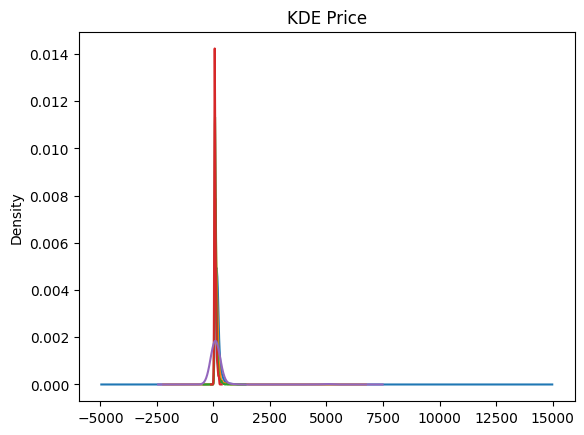

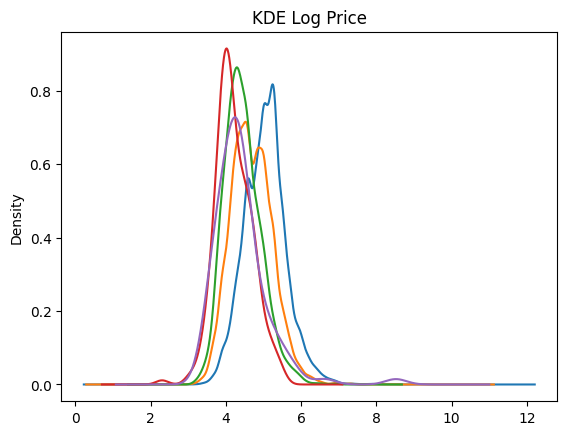

In [6]:
for g in nyc['Neighbourhood'].unique():
    nyc[nyc['Neighbourhood']==g]['Price'].plot(kind='kde')
plt.title("KDE Price")
plt.show()

nyc['log_price'] = np.log(nyc['Price'])
for g in nyc['Neighbourhood'].unique():
    nyc[nyc['Neighbourhood']==g]['log_price'].plot(kind='kde')
plt.title("KDE Log Price")
plt.show()

2.

In [7]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [8]:
X = pd.get_dummies(nyc['Neighbourhood'], drop_first=True)
y = nyc['Price']

model1 = LinearRegression().fit(X, y)
print("Intercept:", model1.intercept_)
print(pd.Series(model1.coef_, index=X.columns))

Intercept: 75.27649769585331
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


In the regression, I dropped one category, Bronx, and kept the intercept. This means that the intercept equals the average price of the Bronx, which is the reference group. Each coefficient for the other neighborhoods represents the difference between that neighborhood’s average price and the Bronx's average price. The regression is essentially reproducing the group means in a different form. The table in part 1 gives absolute averages, while the regression gives those same averages relative to the reference group. The regression coefficients are just re-expressions of the group means, either as differences from a reference group (with an intercept) or as the group means themselves (without an intercept).

3.

In [9]:
X2 = nyc[['Review_Scores_Rating']]
model2 = LinearRegression().fit(X2, y)
print("Slope rating:", model2.coef_[0])

Slope rating: 1.0208266022674763


For each 1 point increase in rating, the expected price increases by about $1.02 on average

4.

In [10]:
X3 = pd.concat([X, X2], axis=1)
model3 = LinearRegression().fit(X3, y)
print(pd.Series(model3.coef_, index=X3.columns))

Brooklyn                 51.704240
Manhattan               108.228737
Queens                   21.694600
Staten Island            71.766552
Review_Scores_Rating      1.081116
dtype: float64


The slope coefficient on review scores rating becomes slightly higher. After controlling for neighborhood, ratings have a slightly stronger positive effect on price. This suggests neighborhood was distorting the relationship a bit. The neighborhood averages are still very similar, showing that the location remains the dominant driver of price.

5.

In [11]:
for col in X.columns:
    nyc[f"{col}_rating"] = X[col] * nyc['Review_Scores_Rating']

X4 = pd.concat([X3, nyc[[c for c in nyc.columns if "_rating" in c]]], axis=1)
model4 = LinearRegression().fit(X4, y)
print(pd.Series(model4.coef_, index=X4.columns))

Brooklyn                 -16.392990
Manhattan                 41.315429
Queens                    28.259701
Staten Island           2963.071040
Review_Scores_Rating       0.574311
Brooklyn_rating            0.741165
Manhattan_rating           0.729703
Queens_rating             -0.072294
Staten Island_rating     -31.831748
dtype: float64


The slopes are not necessarily similar across neighborhoods, but many are fairly similar, ranging around the 0.7 range.

6.

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_mse(X, y):
    mses = []
    for train, test in kf.split(X):
        m = LinearRegression().fit(X.iloc[train], y.iloc[train])
        preds = m.predict(X.iloc[test])
        mses.append(mean_squared_error(y.iloc[test], preds))
    return np.mean(mses)

print("CV MSE model 4:", cv_mse(X3,y))
print("CV MSE model 5:", cv_mse(X4,y))

CV MSE model 4: 21070.14228587856
CV MSE model 5: 21328.18344590853


I used cross validation to evaluate the models from parts 4 and 5. The model with neighborhood and a common rating slope had a lower test MSE than the  model with separate slopes. This suggests that allowing separate slopes by neighborhood does not improve predictive performance and may lead to overfitting.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made




In [13]:
! git clone https://github.com/zry3fr/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 33 (delta 10), reused 4 (delta 4), pack-reused 19 (from 1)
Receiving objects: 100% (33/33), 42.65 KiB | 1.29 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Download complete
Extracting data files...
Data extracted


<Figure size 640x480 with 0 Axes>

1.

In [14]:
cars = pd.read_csv('/content/data/cars_hw.csv')
cars.head(10)

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000
5,6,Hyundai,2016,red,hatchback,52261,1st,5,petrol,5-Speed,Manual,604000
6,7,Honda,2012,grey,hatchback,28108,2nd,5,petrol,5-Speed,Manual,316000
7,8,Tata,2019,grey,suv,92603,1st,5,diesel,6-Speed,Automatic,1419000
8,9,Hyundai,2021,blue,hatchback,16304,1st,5,petrol,5-Speed,Manual,710000
9,10,Renault,2019,bronze,hatchback,26350,2nd,5,petrol,5-Speed,Manual,392000


In [15]:
price_summary = cars['Price'].describe()
price_summary

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


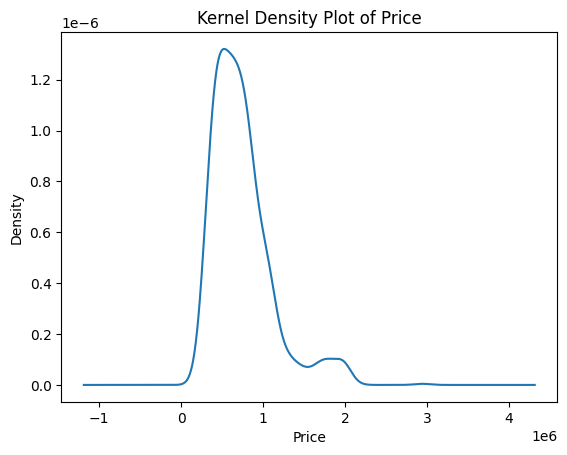

In [16]:
cars['Price'].plot(kind='kde')
plt.title("Kernel Density Plot of Price")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

In [17]:
group_summary = cars.groupby('Body_Type')['Price'].describe()
group_summary

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


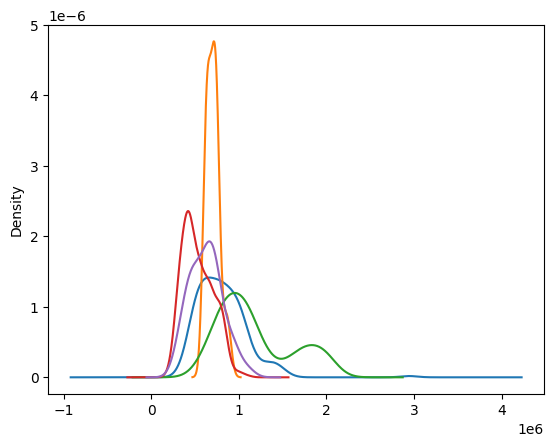

In [18]:
for b in cars['Body_Type'].unique():
    cars[cars['Body_Type']==b]['Price'].plot(kind='kde')
plt.show()

SUVs are the most expensive and also have the highest variance, followed by Sedans. Hatchbacks are the cheapest and least variable.

2.

In [19]:
X = cars[['Seating_Capacity']]
y = cars['Price']
model = LinearRegression().fit(X,y)
print("Slope:", model.coef_[0])

Slope: 59267.99803672175


The slope coefficient is about 59,268. This means that for each additional seat in a car, the predicted price increases by about 59,000 Indian rupees on average.

In [21]:
X_cat = pd.get_dummies(cars['Seating_Capacity'], drop_first=True)
model_cat = LinearRegression().fit(X_cat, y)
print(pd.Series(model_cat.coef_, index=X_cat.columns))

5    5.464839e+05
6    1.456000e+06
7    7.359487e+05
8    2.718000e+05
dtype: float64


No the relationship is not linear because prices do not increase consistently with each additional seat. This shows that seating capacity reflects differences in vehicle type rather than a linear effect.

3.

In [22]:
cars['Age'] = cars['Make_Year'].max() - cars['Make_Year']

In [23]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def cv_poly(d):
    Xp = pd.DataFrame({f'Age^{i}': cars['Age']**i for i in range(1,d+1)})
    mses=[]
    for tr,te in kf.split(Xp):
        m=LinearRegression().fit(Xp.iloc[tr], y.iloc[tr])
        preds=m.predict(Xp.iloc[te])
        mses.append(mean_squared_error(y.iloc[te], preds))
    return np.mean(mses)

res={}
for d in range(1,6):
    res[d]=cv_poly(d)

print(res)
best=min(res,key=res.get)
print("Best degree:", best)

{1: np.float64(97377248063.9968), 2: np.float64(97395705968.63509), 3: np.float64(96743204818.44325), 4: np.float64(96225038252.2612), 5: np.float64(95265035514.25769)}
Best degree: 5


4.

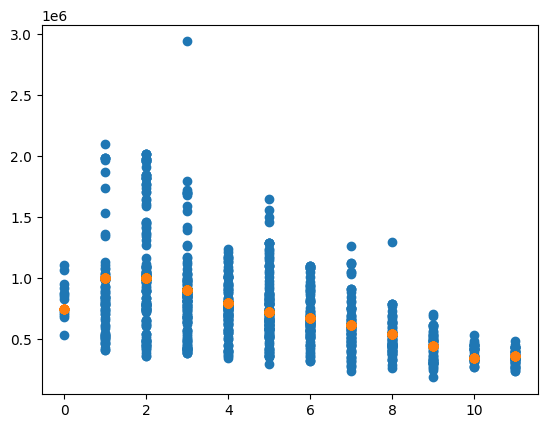

In [24]:
Xp = pd.DataFrame({f'Age^{i}': cars['Age']**i for i in range(1,best+1)})
m=LinearRegression().fit(Xp,y)
cars['pred']=m.predict(Xp)

plt.scatter(cars['Age'], cars['Price'])
plt.scatter(cars['Age'], cars['pred'])
plt.show()

The model fits the overall downward trend in price with age, particularly the decline in price as age increased. Therefore, it is able to capture the main relationship. However, it does not fully capture the variability in the data. There is still noticeable scatter around the predicted values, meaning that cars with the same age can have different prices. This implies that other factors beyond age also influence price.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.



1.

In [25]:
heart = pd.read_csv('/content/heart_hw.csv')
heart.head(10)

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0
5,6,36,control,0
6,7,47,control,0
7,8,41,treatment,0
8,9,47,control,0
9,10,51,control,0


In [26]:
heart['treat'] = (heart['transplant']=='treatment').astype(int)

In [29]:
control_mean = heart[heart['treat']==0]['y'].mean()
treat_mean = heart[heart['treat']==1]['y'].mean()
ate = treat_mean - control_mean

print("Control survival:", control_mean)
print("Treatment survival:", treat_mean)
print("ATE:", ate)

Control survival: 0.11764705882352941
Treatment survival: 0.34782608695652173
ATE: 0.23017902813299232


The ATE is 0.230, meaning that individuals who receive a heart transplant are about 23% more likely to survive for three years than those who do not receive a transplant.

2.

In [36]:
X1 = heart[['treat']]
y = heart['y']
m1 = LinearRegression().fit(X1,y)
print("Model 1:")
print("Intercept:", m1.intercept_)
print("Treat coefficient:", m1.coef_[0])

Model 1:
Intercept: 0.1176470588235293
Treat coefficient: 0.23017902813299249


The intercept equals the control group survival rate and the transplant coefficient equals the ATE. Therefore, the regression matches the difference in means from part 1.

3.

In [38]:
X2 = heart[['treat','age']]
m2 = LinearRegression().fit(X2,y)
print("Model 2:")
print("Intercept:", m2.intercept_)
print("Coefficients:", dict(zip(X2.columns, m2.coef_)))

Model 2:
Intercept: 0.7019569721740947
Coefficients: {'treat': np.float64(0.2647016865036751), 'age': np.float64(-0.013607217160218647)}


Controlling for age increases the transplant effect from 0.230 to 0.265. This indicates that age was confounding the relationship. The intercept is the baseline survival at age zero and the age slope shows survival decreases with age.

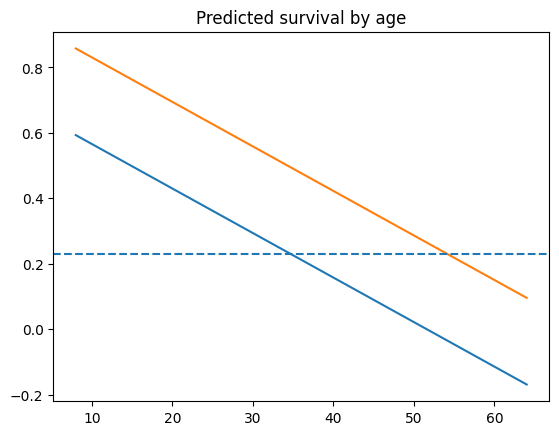

In [39]:
ages = np.linspace(heart['age'].min(), heart['age'].max(),100)
pred_control = m2.predict(pd.DataFrame({'treat':0,'age':ages}))
pred_treat = m2.predict(pd.DataFrame({'treat':1,'age':ages}))

plt.plot(ages, pred_control)
plt.plot(ages, pred_treat)
plt.axhline(y=ate, linestyle='--')
plt.title("Predicted survival by age")
plt.show()

The ATE overestimates the treatment effect for younger ages (roughly ages below 35) and underestimates it for older ages (roughly ages above 35). This is because the true impact of a transplant varies with age while the ATE is constant.

4.

In [41]:
heart['treat_age'] = heart['treat']*heart['age']
X3 = heart[['treat','age','treat_age']]
m3 = LinearRegression().fit(X3,y)
print("Model 3 (interaction):")
print("Intercept:", m3.intercept_)
print("Coefficients:", dict(zip(X3.columns, m3.coef_)))

Model 3 (interaction):
Intercept: 0.35486517529945855
Coefficients: {'treat': np.float64(0.9077513885685898), 'age': np.float64(-0.0055242575069736986), 'treat_age': np.float64(-0.01459063825685528)}


When the interaction between transplant and age is included, the effect of a transplant is no longer constant and instead depends on age. The negative interaction coefficient (−0.0146) shows that each additional year of age reduces the benefit of a transplant. Therefore, the transplant effect decreases with age, meaning younger patients benefit more. Unlike part 3, the treatment effect is no longer constant and the ATE misleads the effect across ages by over- and under-estimating.

5.

In [42]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def cv(X):
    mses=[]
    for tr,te in kf.split(X):
        m=LinearRegression().fit(X.iloc[tr], y.iloc[tr])
        preds=m.predict(X.iloc[te])
        mses.append(mean_squared_error(y.iloc[te], preds))
    return np.mean(mses)

print("CV MSE:")
print("Model1:", cv(X1))
print("Model2:", cv(X2))
print("Model3:", cv(X3))

CV MSE:
Model1: 0.1930687841733136
Model2: 0.1772665165855078
Model3: 0.17512042221989654


6.

A concern is that the model is oversimplified, because it only includes age and transplant status. It ignores many important medical factors, such as underlying conditions, severity of disease, or overall health, which could lead to inaccurate or harmful decisions. Additionally with data collection, the model may have selection bias. Patients who receive transplants are not randomly selected. They may differ in health status, severity of disease, or access to healthcare. This means the estimated treatment effects may not reflect true causal effects.